# 04 — Feature Engineering

## Projet : Smart City Energy Forecasting — Tetouan

**Correspondance méthodologique :** Ce notebook couvre l'étape **11 (Feature Engineering / Transformation)** de la méthodologie KDD.

### Objectifs

- Charger le dataset horaire propre issu du notebook `03_preprocessing.ipynb` ;
- Créer les features temporelles, cycliques, calendaires, météo, lags et rolling ;
- Vérifier la cohérence des features et l'absence de fuite de données ;
- Sauvegarder `data/processed/tetouan_features.csv` ;
- Calculer les baselines naïves : heure précédente, jour précédent, semaine précédente.

### Pipeline de features

| Étape | Section | Description |
|-------|---------|-------------|
| 11.1 | Features temporelles | heure, jour de semaine, mois, trimestre, jour de l'année |
| 11.2 | Encodage cyclique sin/cos | Proximité entre 23h et 0h |
| 11.3 | Week-end | Changement d'activité humaine |
| 11.4 | Heures de pointe | Matin 07h–09h, soir 18h–21h |
| 11.5 | Heures creuses | 00h–05h |
| 11.6 | Saison | Effets climatiques saisonniers |
| 11.7 | Jours fériés marocains | Fichier externe ou liste indicative |
| 11.8 | Lag features | 1h → 168h |
| 11.9 | Rolling features | Moyenne, écart-type, min, max sur 3h → 168h |
| 11.10 | HDD / CDD | Besoins de chauffage / climatisation |
| 11.11 | Interactions météo | Température × humidité, CDD × peak, etc. |
| 11.12 | Variables de robustesse | is_high_temperature, is_high_load, etc. |
| 11.13 | Point méthodologique | Proxys temporels pour l'activité humaine |


## 1. Imports et configuration

Le notebook utilise les fonctions modulaires définies dans :

- `src/features.py` ;
- `src/models_baseline.py`.

Le code est conçu pour être exécuté depuis le dossier `notebooks/` ou depuis la racine du projet.

In [48]:
import sys
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Résolution du chemin projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Importation des modules locaux
from src.features import (
    FeatureConfig,
    build_feature_dataset,
    check_rolling_no_leakage,
    get_model_feature_columns,
    load_holidays_from_csv,
    save_feature_dataset,
    validate_feature_dataset,
    # Fonctions individuelles pour la démonstration pas-à-pas
    ensure_datetime_index,
    add_temporal_features,
    add_cyclical_features,
    add_holiday_features,
    add_lag_features,
    add_rolling_features,
    add_weather_features,
    add_robustness_flags,
    MOROCCO_HOLIDAYS_2017_INDICATIVE,
)

from src.models_baseline import (
    evaluate_naive_baselines,
    save_baseline_outputs,
)

# Chemins du projet
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "Tetuan City power consumption.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_PRED_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"

FEATURES_PATH = PROCESSED_DIR / "tetouan_features.csv"
FEATURE_COLUMNS_PATH = PROCESSED_DIR / "feature_columns.txt"
BASELINE_METRICS_PATH = RESULTS_METRICS_DIR / "baseline_naive_metrics.csv"
BASELINE_PRED_PATH = RESULTS_PRED_DIR / "baseline_naive_predictions.csv"
BASELINE_FIG_PATH = RESULTS_FIG_DIR / "baseline_naive_test_week.png"

for path in [PROCESSED_DIR, EXTERNAL_DIR, RESULTS_METRICS_DIR, RESULTS_PRED_DIR, RESULTS_FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", PROJECT_ROOT)
print("✅ Bibliothèques et modules locaux importés avec succès.")

Racine du projet : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan
✅ Bibliothèques et modules locaux importés avec succès.


## 2. Chargement du dataset horaire propre

La source recommandée est le fichier horaire propre produit par le prétraitement.

Le notebook cherche dans cet ordre :

1. `data/processed/tetouan_hourly_clean.csv`
2. `data/processed/tetouan_hourly.csv`

Si aucun de ces fichiers n'existe, le notebook reconstruit une version horaire depuis le CSV brut `data/raw/Tetuan City power consumption.csv`.

Cette reconstruction de secours permet d'exécuter le notebook même si le fichier horaire n'a pas encore été sauvegardé par le notebook 03.

In [49]:
COLUMN_MAPPING = {
    "DateTime": "datetime",
    "Temperature": "temperature",
    "Humidity": "humidity",
    "Wind Speed": "wind_speed",
    "general diffuse flows": "general_diffuse_flows",
    "diffuse flows": "diffuse_flows",
    "Zone 1 Power Consumption": "zone1_power",
    "Zone 2  Power Consumption": "zone2_power",
    "Zone 3  Power Consumption": "zone3_power",
}


def load_hourly_dataset(project_root: Path) -> pd.DataFrame:
    """
    Charge le dataset horaire propre si disponible.
    Sinon, reconstruit un dataset horaire à partir du CSV brut.
    """
    candidates = [
        project_root / "data" / "processed" / "tetouan_hourly_clean.csv",
        project_root / "data" / "processed" / "tetouan_hourly.csv",
    ]

    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)

            if "datetime" in df.columns:
                df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
                df = df.set_index("datetime")
            else:
                first_col = df.columns[0]
                df[first_col] = pd.to_datetime(df[first_col], errors="coerce")
                df = df.set_index(first_col)
                df.index.name = "datetime"

            df = df.sort_index()

            print(f"Dataset horaire chargé depuis : {path}")
            return df

    if not RAW_PATH.exists():
        raise FileNotFoundError(
            "Aucun fichier horaire trouvé et CSV brut introuvable. "
            "Vérifier data/processed/ ou data/raw/."
        )

    raw = pd.read_csv(RAW_PATH)
    raw = raw.rename(columns=COLUMN_MAPPING)
    raw["datetime"] = pd.to_datetime(raw["datetime"], errors="coerce")

    if raw["datetime"].isna().any():
        n_bad = int(raw["datetime"].isna().sum())
        raise ValueError(f"{n_bad} dates non convertibles détectées dans le CSV brut.")

    raw = raw.sort_values("datetime").set_index("datetime")
    for col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

    hourly = raw.resample("1h").mean()
    hourly["target"] = hourly["zone1_power"]
    hourly["total_load"] = hourly["zone1_power"] + hourly["zone2_power"] + hourly["zone3_power"]

    print("Aucun fichier horaire prétraité trouvé : dataset horaire reconstruit depuis le CSV brut.")
    return hourly


df_hourly = load_hourly_dataset(PROJECT_ROOT)

# Assurer la présence de target et total_load
if "target" not in df_hourly.columns:
    df_hourly["target"] = df_hourly["zone1_power"]
if "total_load" not in df_hourly.columns:
    df_hourly["total_load"] = df_hourly["zone1_power"] + df_hourly["zone2_power"] + df_hourly["zone3_power"]

df_hourly = df_hourly.sort_index()

print(f"\nDimensions du dataset horaire : {df_hourly.shape}")
print(f"Période : {df_hourly.index.min()} → {df_hourly.index.max()}")
print(f"Fréquence inférée : {pd.infer_freq(df_hourly.index)}")
print(f"Valeurs manquantes : {int(df_hourly.isna().sum().sum())}")
print(f"Doublons temporels : {int(df_hourly.index.duplicated().sum())}")

display(df_hourly.head())

Dataset horaire chargé depuis : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\tetouan_hourly_clean.csv

Dimensions du dataset horaire : (8736, 15)
Période : 2017-01-01 00:00:00 → 2017-12-30 23:00:00
Fréquence inférée : h
Valeurs manquantes : 0
Doublons temporels : 0


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load,target_rolling_zscore,total_load_rolling_zscore,is_target_outlier,is_total_load_outlier,is_load_outlier
datetime,,,,,,,,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193,29197.974683,66476.770597,0.000000,0.000000,0.0,0.0,0.0
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567,24657.215190,57778.526210,0.000000,0.000000,0.0,0.0,0.0
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578,22083.037973,52089.881640,1.284239,1.472345,0.0,0.0,0.0
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422,20811.139240,48914.447548,1.151379,1.294989,0.0,0.0,0.0
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433,20475.949367,47714.638347,1.008644,1.100811,0.0,0.0,0.0


## 3. Configuration du Feature Engineering

Les paramètres du pipeline sont centralisés dans `FeatureConfig`.

### Lags retenus

| Lag | Rôle |
|-----|------|
| 1h, 2h, 3h | Inertie immédiate |
| 6h, 12h | Dynamique intra-journalière |
| 24h, 48h, 72h | Même heure les jours précédents |
| 168h | Même heure la semaine précédente |

### Rolling features

Les rolling features sont calculées à partir de la cible décalée avec `shift(1)`, donc elles n'utilisent **jamais** la valeur actuelle à prédire.

Le seuil de forte charge est calculé **uniquement sur la partie train** afin d'éviter toute fuite d'information depuis le futur.

In [50]:
config = FeatureConfig(
    target_col="target",
    temperature_col="temperature",
    humidity_col="humidity",
    general_diffuse_col="general_diffuse_flows",
    diffuse_col="diffuse_flows",
    temperature_base=18.0,
    lags=(1, 2, 3, 6, 12, 24, 48, 72, 168),
    rolling_windows=(3, 6, 12, 24, 48, 168),
    high_temperature_threshold=30.0,
    dropna_after_features=True,
)

# Seuil forte charge calculé uniquement sur le train (70%)
train_end = int(len(df_hourly) * 0.70)
high_load_threshold_train = (
    df_hourly["target"]
    .iloc[:train_end]
    .quantile(config.high_load_quantile)
)

print(f"Seuil forte charge calculé sur train seulement : {high_load_threshold_train:.2f}")
print(f"\nConfiguration du pipeline :")
print(f"  - Target : {config.target_col}")
print(f"  - Température de base HDD/CDD : {config.temperature_base}°C")
print(f"  - Lags : {config.lags}")
print(f"  - Rolling windows : {config.rolling_windows}")
print(f"  - Seuil haute température : {config.high_temperature_threshold}°C")

Seuil forte charge calculé sur train seulement : 44816.11

Configuration du pipeline :
  - Target : target
  - Température de base HDD/CDD : 18.0°C
  - Lags : (1, 2, 3, 6, 12, 24, 48, 72, 168)
  - Rolling windows : (3, 6, 12, 24, 48, 168)
  - Seuil haute température : 30.0°C


---
## 11.1 Features temporelles

**Pourquoi :** Les cycles d'activité humaine suivent des patterns temporels réguliers : heures de travail, jours ouvrables, saisons.

**Variables créées :**

- `hour` : heure (0–23)
- `dayofweek` : jour de semaine (0=lundi, 6=dimanche)
- `dayofmonth` : jour du mois
- `dayofyear` : jour de l'année (1–365)
- `weekofyear` : semaine ISO
- `month` : mois (1–12)
- `quarter` : trimestre (1–4)

**Interprétation :** Ces variables sont des proxys pour l'activité humaine, car le dataset Tetouan ne contient pas d'observations directes de l'activité urbaine.

Features temporelles créées :


,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter
datetime,,,,,,,
2017-01-01 00:00:00,0,6,1,1,52,1,1
2017-01-01 01:00:00,1,6,1,1,52,1,1
2017-01-01 02:00:00,2,6,1,1,52,1,1
2017-01-01 03:00:00,3,6,1,1,52,1,1
2017-01-01 04:00:00,4,6,1,1,52,1,1
2017-01-01 05:00:00,5,6,1,1,52,1,1
2017-01-01 06:00:00,6,6,1,1,52,1,1
2017-01-01 07:00:00,7,6,1,1,52,1,1
2017-01-01 08:00:00,8,6,1,1,52,1,1


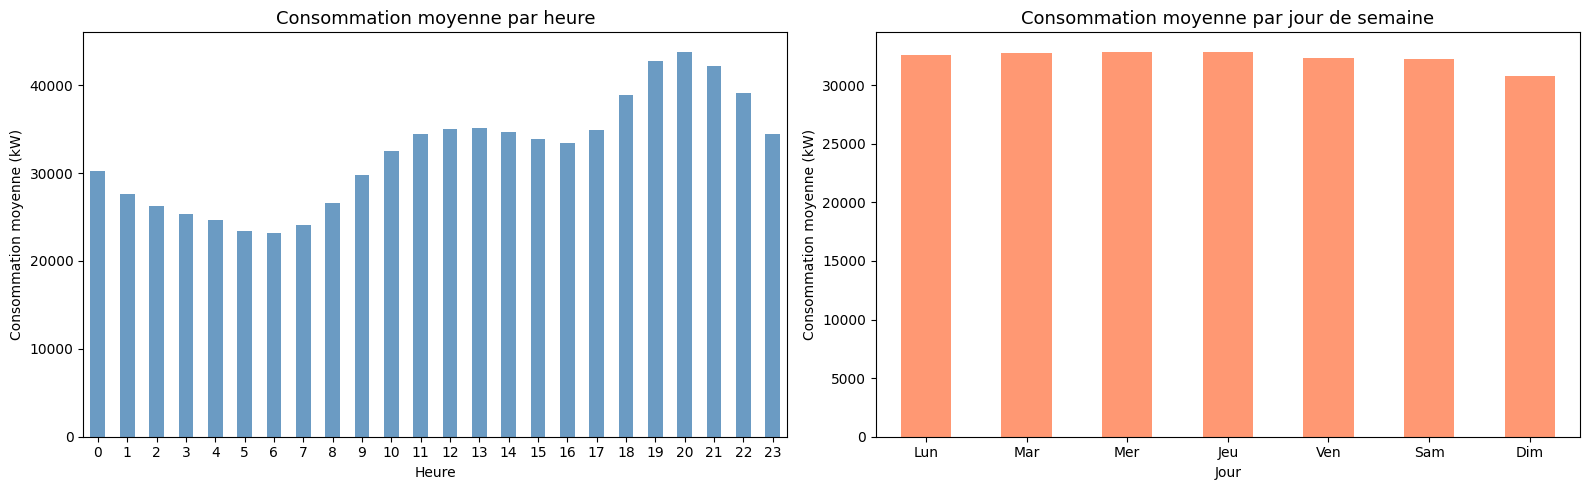


✅ 7 features temporelles ajoutées.


In [51]:
# Application de la fonction add_temporal_features
df_step = ensure_datetime_index(df_hourly.copy())
df_step = add_temporal_features(df_step)

# Affichage des colonnes temporelles créées
temporal_cols = ["hour", "dayofweek", "dayofmonth", "dayofyear", "weekofyear", "month", "quarter"]
print("Features temporelles créées :")
display(df_step[temporal_cols].head(10))

# Visualisation : distribution de la consommation par heure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_step.groupby("hour")["target"].mean().plot(kind="bar", ax=axes[0], color="steelblue", alpha=0.8)
axes[0].set_title("Consommation moyenne par heure", fontsize=13)
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Consommation moyenne (kW)")
axes[0].tick_params(axis="x", rotation=0)

df_step.groupby("dayofweek")["target"].mean().plot(
    kind="bar", ax=axes[1], color="coral", alpha=0.8
)
day_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
axes[1].set_xticklabels(day_labels, rotation=0)
axes[1].set_title("Consommation moyenne par jour de semaine", fontsize=13)
axes[1].set_xlabel("Jour")
axes[1].set_ylabel("Consommation moyenne (kW)")

plt.tight_layout()
plt.show()

print(f"\n✅ {len(temporal_cols)} features temporelles ajoutées.")

## 11.2 Encodage cyclique sin/cos

**Pourquoi :** L'heure 23 et l'heure 0 sont proches dans le cycle journalier. Un encodage numérique simple ne capture pas cette proximité.

**Formule :**

```python
hour_sin = sin(2 * pi * hour / 24)
hour_cos = cos(2 * pi * hour / 24)
```

Même logique pour le jour de semaine, le mois et le jour de l'année.

**Interprétation :** Sur le cercle unitaire, les heures 23 et 0 sont voisines, ce qui est mathématiquement correct pour un modèle de régression.

Features cycliques créées :


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos
datetime,,,,,,,,
2017-01-01 00:00:00,0.000000,1.000000e+00,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 01:00:00,0.258819,9.659258e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 02:00:00,0.500000,8.660254e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 03:00:00,0.707107,7.071068e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 04:00:00,0.866025,5.000000e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 05:00:00,0.965926,2.588190e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 06:00:00,1.000000,6.123234e-17,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 07:00:00,0.965926,-2.588190e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852
2017-01-01 08:00:00,0.866025,-5.000000e-01,-0.781831,0.62349,0.0,1.0,0.017213,0.999852


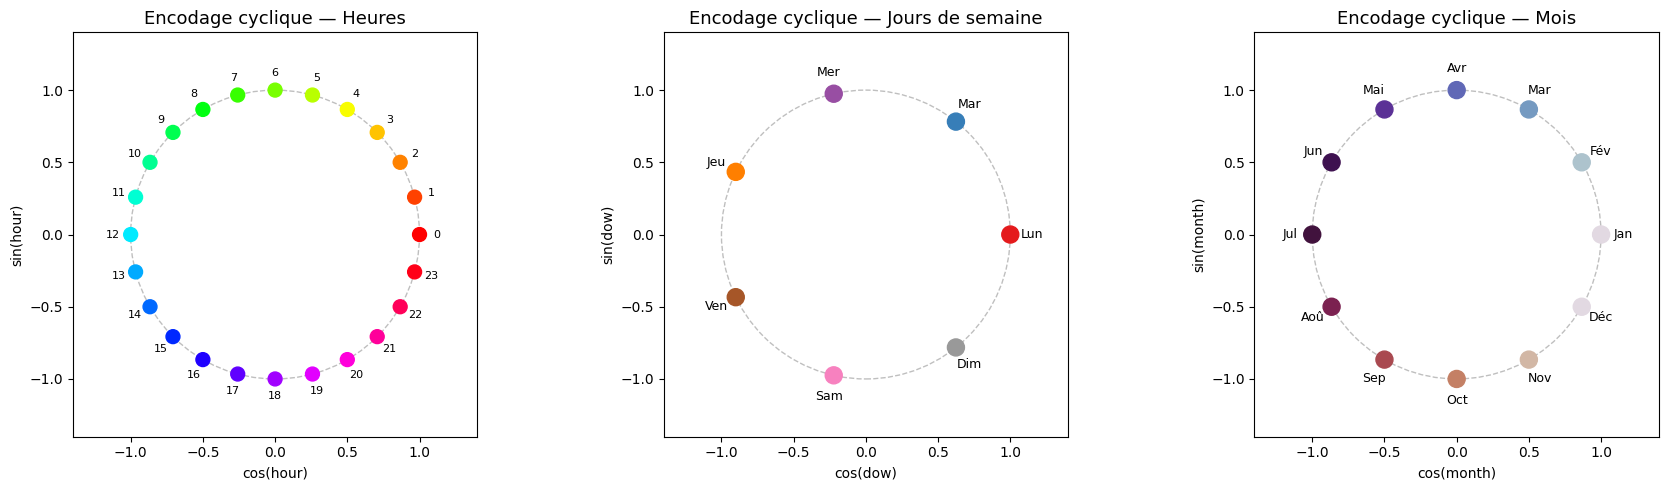


✅ 8 features cycliques sin/cos ajoutées.


In [52]:
# Application de l'encodage cyclique
df_step = add_cyclical_features(df_step)

cyclical_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos",
                 "month_sin", "month_cos", "doy_sin", "doy_cos"]
print("Features cycliques créées :")
display(df_step[cyclical_cols].head(10))

# Visualisation : encodage cyclique de l'heure sur le cercle unitaire
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cercle des heures
hours = np.arange(24)
h_sin = np.sin(2 * np.pi * hours / 24)
h_cos = np.cos(2 * np.pi * hours / 24)
axes[0].scatter(h_cos, h_sin, c=hours, cmap="hsv", s=100, zorder=5)
for h in hours:
    axes[0].annotate(str(h), (h_cos[h]*1.12, h_sin[h]*1.12), ha="center", va="center", fontsize=8)
circle = plt.Circle((0, 0), 1, fill=False, color="gray", linestyle="--", alpha=0.5)
axes[0].add_patch(circle)
axes[0].set_xlim(-1.4, 1.4)
axes[0].set_ylim(-1.4, 1.4)
axes[0].set_aspect("equal")
axes[0].set_title("Encodage cyclique — Heures", fontsize=13)
axes[0].set_xlabel("cos(hour)")
axes[0].set_ylabel("sin(hour)")

# Cercle des jours de semaine
days = np.arange(7)
d_sin = np.sin(2 * np.pi * days / 7)
d_cos = np.cos(2 * np.pi * days / 7)
axes[1].scatter(d_cos, d_sin, c=days, cmap="Set1", s=150, zorder=5)
for d in days:
    axes[1].annotate(day_labels[d], (d_cos[d]*1.15, d_sin[d]*1.15), ha="center", va="center", fontsize=9)
circle2 = plt.Circle((0, 0), 1, fill=False, color="gray", linestyle="--", alpha=0.5)
axes[1].add_patch(circle2)
axes[1].set_xlim(-1.4, 1.4)
axes[1].set_ylim(-1.4, 1.4)
axes[1].set_aspect("equal")
axes[1].set_title("Encodage cyclique — Jours de semaine", fontsize=13)
axes[1].set_xlabel("cos(dow)")
axes[1].set_ylabel("sin(dow)")

# Cercle des mois
months = np.arange(12)
m_sin = np.sin(2 * np.pi * months / 12)
m_cos = np.cos(2 * np.pi * months / 12)
month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]
axes[2].scatter(m_cos, m_sin, c=months, cmap="twilight", s=150, zorder=5)
for m in months:
    axes[2].annotate(month_labels[m], (m_cos[m]*1.15, m_sin[m]*1.15), ha="center", va="center", fontsize=9)
circle3 = plt.Circle((0, 0), 1, fill=False, color="gray", linestyle="--", alpha=0.5)
axes[2].add_patch(circle3)
axes[2].set_xlim(-1.4, 1.4)
axes[2].set_ylim(-1.4, 1.4)
axes[2].set_aspect("equal")
axes[2].set_title("Encodage cyclique — Mois", fontsize=13)
axes[2].set_xlabel("cos(month)")
axes[2].set_ylabel("sin(month)")

plt.tight_layout()
plt.show()

print(f"\n✅ {len(cyclical_cols)} features cycliques sin/cos ajoutées.")

## 11.3 Week-end

**Formule :**

```python
is_weekend = 1 si samedi ou dimanche, sinon 0
```

**Pourquoi :** Cette variable représente un changement d'activité humaine. Les week-ends présentent typiquement des profils de consommation différents (moins d'activité industrielle et commerciale).

**Interprétation :** On s'attend à une consommation plus faible le week-end, particulièrement en heures ouvrables.

Distribution is_weekend :
is_weekend
0    6240
1    2496
Name: count, dtype: int64

Pourcentage de week-end : 28.6%


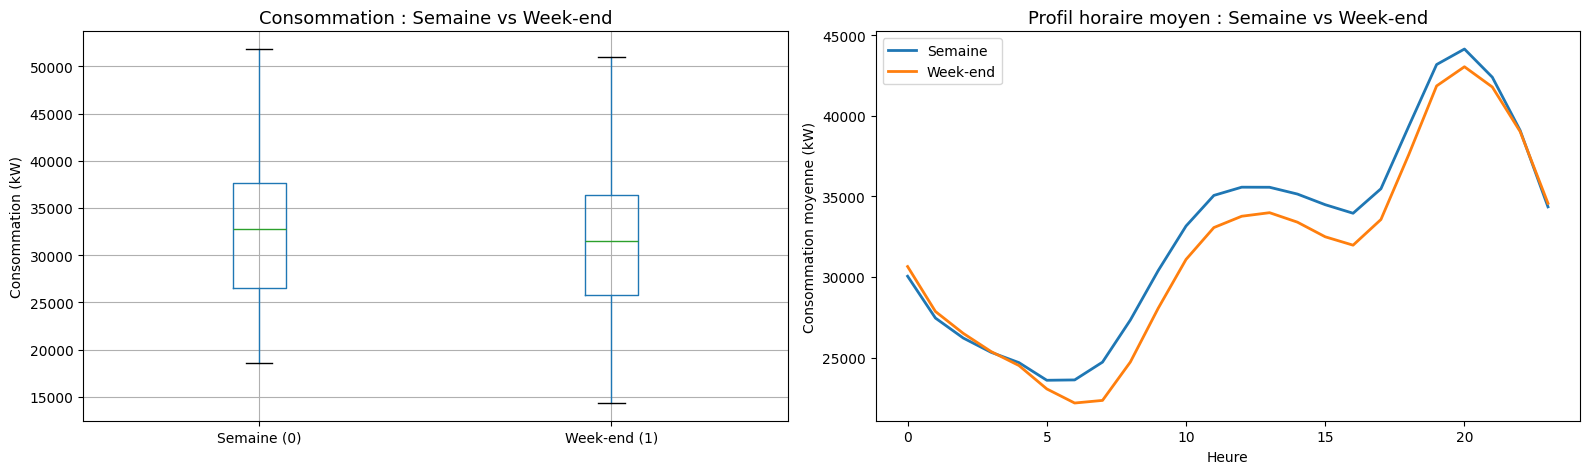


Statistiques descriptives :


,mean,std,min,max
Semaine,32676.336024,7059.138599,18551.077313,51844.261932
Week-end,31516.556913,7026.667306,14329.113923,51010.764120


In [53]:
# is_weekend a déjà été créé par add_temporal_features
# Vérifions la distribution
print("Distribution is_weekend :")
print(df_step["is_weekend"].value_counts())
print(f"\nPourcentage de week-end : {df_step["is_weekend"].mean()*100:.1f}%")

# Visualisation : boxplot consommation week-end vs semaine
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_step.boxplot(column="target", by="is_weekend", ax=axes[0])
axes[0].set_xticklabels(["Semaine (0)", "Week-end (1)"])
axes[0].set_title("Consommation : Semaine vs Week-end", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Consommation (kW)")
plt.suptitle("")

# Profil horaire moyen : semaine vs week-end
for label, group in df_step.groupby("is_weekend"):
    name = "Week-end" if label == 1 else "Semaine"
    group.groupby("hour")["target"].mean().plot(ax=axes[1], label=name, linewidth=2)
axes[1].set_title("Profil horaire moyen : Semaine vs Week-end", fontsize=13)
axes[1].set_xlabel("Heure")
axes[1].set_ylabel("Consommation moyenne (kW)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistiques descriptives
weekend_stats = df_step.groupby("is_weekend")["target"].agg(["mean", "std", "min", "max"])
weekend_stats.index = ["Semaine", "Week-end"]
print("\nStatistiques descriptives :")
display(weekend_stats)

## 11.4 Heures de pointe

Les heures de pointe sont définies par hypothèse métier :

- **Matin :** 07h–09h (`is_morning_peak`)
- **Soir :** 18h–21h (`is_evening_peak`)
- **Combiné :** `is_peak_hour` = matin OU soir

**Pourquoi :** Les pics de consommation correspondent aux heures de démarrage de l'activité (matin) et de retour au domicile (soir). Ces bornes pourront être ajustées après l'EDA.

**Variable supplémentaire :** `is_business_hour` = 08h–18h en semaine.

Distribution des indicateurs de pointe :
  is_morning_peak : 1092 heures (12.5%)
  is_evening_peak : 1456 heures (16.7%)
  is_peak_hour : 2548 heures (29.2%)
  is_business_hour : 2860 heures (32.7%)


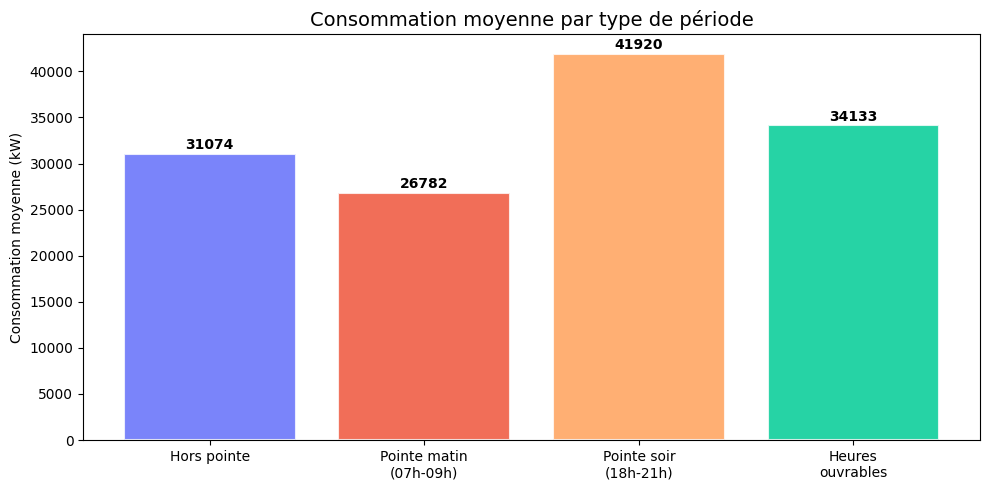

In [54]:
# Vérification des heures de pointe
peak_cols = ["is_morning_peak", "is_evening_peak", "is_peak_hour", "is_business_hour"]
print("Distribution des indicateurs de pointe :")
for col in peak_cols:
    print(f"  {col} : {df_step[col].sum()} heures ({df_step[col].mean()*100:.1f}%)")

# Visualisation : consommation moyenne par type de période
fig, ax = plt.subplots(figsize=(10, 5))

categories = {
    "Hors pointe": df_step[df_step["is_peak_hour"] == 0]["target"].mean(),
    "Pointe matin\n(07h-09h)": df_step[df_step["is_morning_peak"] == 1]["target"].mean(),
    "Pointe soir\n(18h-21h)": df_step[df_step["is_evening_peak"] == 1]["target"].mean(),
    "Heures\nouvrables": df_step[df_step["is_business_hour"] == 1]["target"].mean(),
}

colors = ["#636EFA", "#EF553B", "#FFA15A", "#00CC96"]
bars = ax.bar(categories.keys(), categories.values(), color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, categories.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f"{val:.0f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Consommation moyenne par type de période", fontsize=14)
ax.set_ylabel("Consommation moyenne (kW)")
plt.tight_layout()
plt.show()

## 11.5 Heures creuses

Les heures creuses sont définies entre **00h et 05h** (`is_off_peak`).

**Pourquoi :** Cette variable est utile pour comparer l'erreur de prédiction en période basse et en période haute.

**Variable supplémentaire :** `is_night` = 23h à 05h (inclut la transition fin/début de journée).

Distribution des heures creuses et nocturnes :
  is_off_peak : 2184 heures (25.0%)
  is_night : 2548 heures (29.2%)


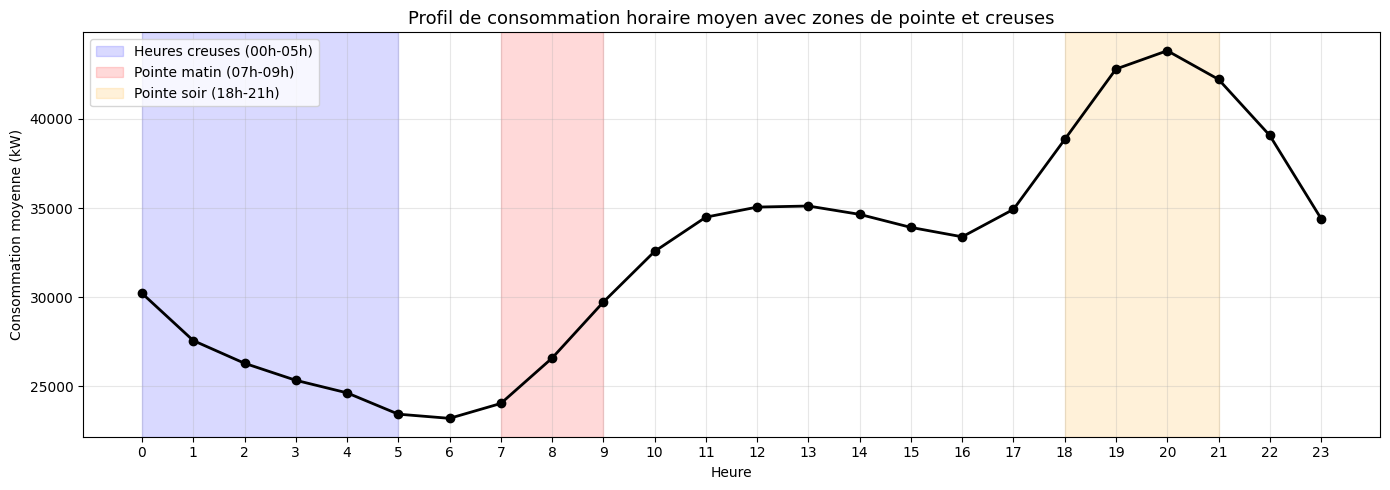

In [55]:
offpeak_cols = ["is_off_peak", "is_night"]
print("Distribution des heures creuses et nocturnes :")
for col in offpeak_cols:
    print(f"  {col} : {df_step[col].sum()} heures ({df_step[col].mean()*100:.1f}%)")

# Visualisation : profil horaire avec zones colorées
fig, ax = plt.subplots(figsize=(14, 5))

hourly_mean = df_step.groupby("hour")["target"].mean()
ax.plot(hourly_mean.index, hourly_mean.values, "ko-", linewidth=2, markersize=6)

# Zones colorées
ax.axvspan(0, 5, alpha=0.15, color="blue", label="Heures creuses (00h-05h)")
ax.axvspan(7, 9, alpha=0.15, color="red", label="Pointe matin (07h-09h)")
ax.axvspan(18, 21, alpha=0.15, color="orange", label="Pointe soir (18h-21h)")

ax.set_title("Profil de consommation horaire moyen avec zones de pointe et creuses", fontsize=13)
ax.set_xlabel("Heure")
ax.set_ylabel("Consommation moyenne (kW)")
ax.set_xticks(range(24))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11.6 Saison

La saison permet de représenter les effets climatiques :

| Mois | Saison |
|------|--------|
| Déc, Jan, Fév | Hiver |
| Mar, Avr, Mai | Printemps |
| Jun, Jul, Aoû | Été |
| Sep, Oct, Nov | Automne |

**Variables créées :**

- `season` (catégorielle)
- `season_code` (numérique : 0–3)
- `season_winter`, `season_spring`, `season_summer`, `season_autumn` (one-hot)

**Interprétation :** L'été à Tétouan implique une forte demande de climatisation (CDD), tandis que l'hiver implique un besoin de chauffage (HDD).

Distribution par saison :
season
spring    2208
summer    2208
autumn    2184
winter    2136
Name: count, dtype: int64


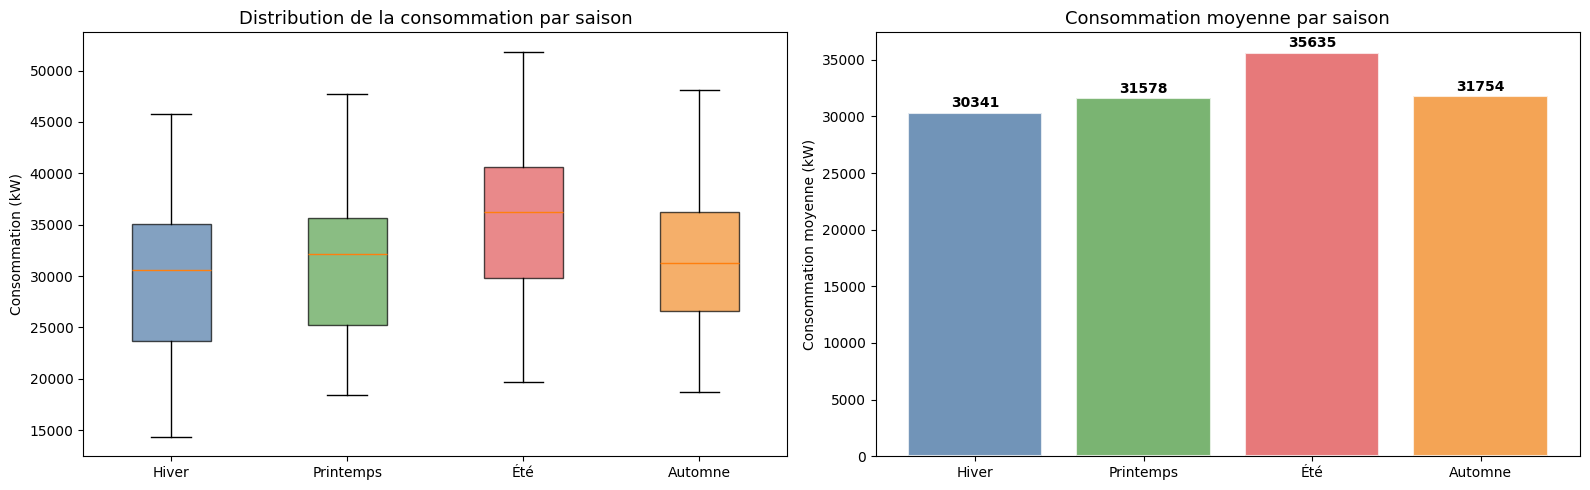

In [56]:
# Vérification de la distribution saisonnière
print("Distribution par saison :")
print(df_step["season"].value_counts())

# Visualisation : boxplot par saison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

season_order = ["winter", "spring", "summer", "autumn"]
season_labels = ["Hiver", "Printemps", "Été", "Automne"]
season_colors = ["#4E79A7", "#59A14F", "#E15759", "#F28E2B"]

# Boxplot
data_by_season = [df_step[df_step["season"] == s]["target"].values for s in season_order]
bp = axes[0].boxplot(data_by_season, labels=season_labels, patch_artist=True)
for patch, color in zip(bp["boxes"], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Distribution de la consommation par saison", fontsize=13)
axes[0].set_ylabel("Consommation (kW)")

# Moyenne par saison
means = [df_step[df_step["season"] == s]["target"].mean() for s in season_order]
bars = axes[1].bar(season_labels, means, color=season_colors, alpha=0.8, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f"{val:.0f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_title("Consommation moyenne par saison", fontsize=13)
axes[1].set_ylabel("Consommation moyenne (kW)")

plt.tight_layout()
plt.show()

## 11.7 Jours fériés marocains

Les jours fériés peuvent être ajoutés sous forme de fichier externe `data/external/holidays_morocco.csv`.

Si le fichier n'est pas disponible, une **liste indicative pour 2017** est utilisée, intégrée dans `src/features.py`.

**Variables créées :**

- `is_holiday` : 1 si jour férié, 0 sinon
- `is_day_before_holiday` : veille de jour férié
- `is_day_after_holiday` : lendemain de jour férié
- `days_to_nearest_holiday` : distance au jour férié le plus proche (max 7)

**⚠️ Point méthodologique :** Les dates des fêtes religieuses musulmanes dépendent de l'observation lunaire. Cette approximation doit être mentionnée dans le rapport final.

Aucun fichier holidays_morocco.csv trouvé : utilisation de la liste indicative intégrée.

Jours fériés marocains 2017 (liste indicative) :
  - 2017-01-01 (Sunday)
  - 2017-01-11 (Wednesday)
  - 2017-05-01 (Monday)
  - 2017-06-26 (Monday)
  - 2017-06-27 (Tuesday)
  - 2017-07-30 (Sunday)
  - 2017-08-14 (Monday)
  - 2017-08-20 (Sunday)
  - 2017-08-21 (Monday)
  - 2017-09-01 (Friday)
  - 2017-09-02 (Saturday)
  - 2017-09-22 (Friday)
  - 2017-11-06 (Monday)
  - 2017-11-18 (Saturday)
  - 2017-12-01 (Friday)

Nombre de jours fériés dans le dataset : 15 jours


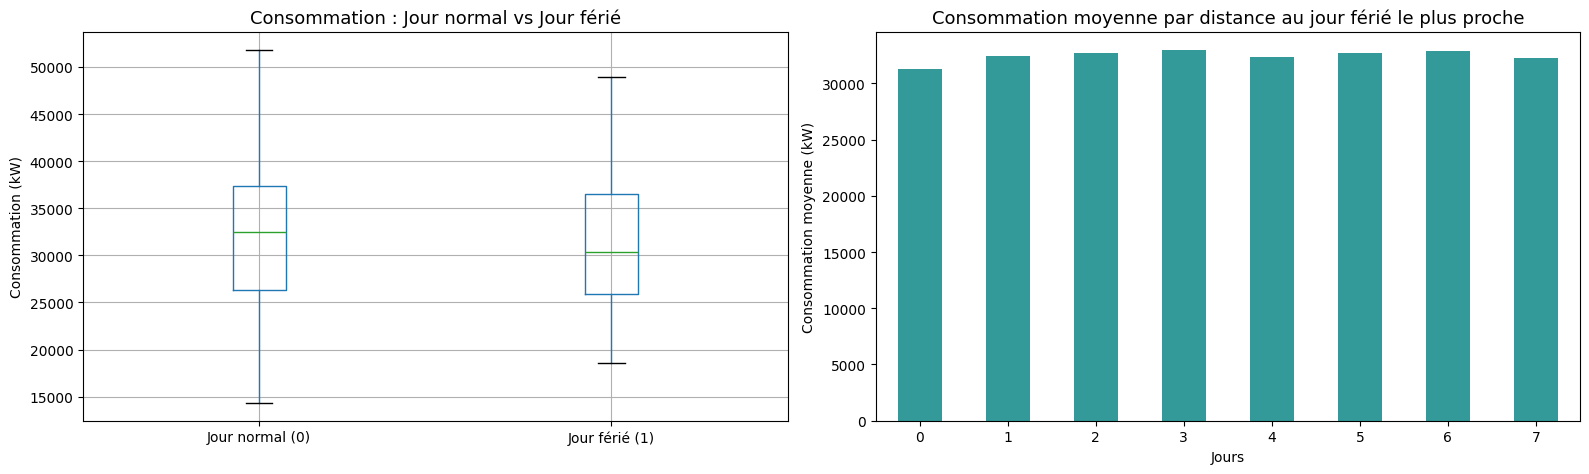

In [57]:
# Chargement des jours fériés
holidays_path = EXTERNAL_DIR / "holidays_morocco.csv"

if holidays_path.exists():
    holidays = load_holidays_from_csv(holidays_path)
    print(f"Jours fériés chargés depuis {holidays_path} : {len(holidays)} dates")
else:
    holidays = None
    print("Aucun fichier holidays_morocco.csv trouvé : utilisation de la liste indicative intégrée.")

# Affichage de la liste indicative
print("\nJours fériés marocains 2017 (liste indicative) :")
for date in MOROCCO_HOLIDAYS_2017_INDICATIVE:
    print(f"  - {date.strftime("%Y-%m-%d (%A)")}")

# Application
df_step = add_holiday_features(df_step, holidays=holidays)

# Vérification
holiday_cols = ["is_holiday", "is_day_before_holiday", "is_day_after_holiday", "days_to_nearest_holiday"]
print(f"\nNombre de jours fériés dans le dataset : {df_step["is_holiday"].sum() // 24} jours")

# Visualisation : effet des jours fériés
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
df_step.boxplot(column="target", by="is_holiday", ax=axes[0])
axes[0].set_xticklabels(["Jour normal (0)", "Jour férié (1)"])
axes[0].set_title("Consommation : Jour normal vs Jour férié", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Consommation (kW)")
plt.suptitle("")

# Distance au jour férié
df_step.groupby("days_to_nearest_holiday")["target"].mean().plot(
    kind="bar", ax=axes[1], color="teal", alpha=0.8
)
axes[1].set_title("Consommation moyenne par distance au jour férié le plus proche", fontsize=13)
axes[1].set_xlabel("Jours")
axes[1].set_ylabel("Consommation moyenne (kW)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 11.8 Lag features

Les lags recommandés après resampling horaire :

| Lag | Rôle |
|-----|------|
| 1h, 2h, 3h | Inertie immédiate |
| 6h | Demi-journée |
| 12h | Cycle AM/PM |
| 24h | Même heure hier |
| 48h | Même heure avant-hier |
| 72h | Même heure il y a 3 jours |
| 168h | Même heure la semaine précédente |

**Pourquoi :** Ces lags capturent l'inertie immédiate, le cycle journalier et le cycle hebdomadaire de la consommation.

**Remarque :** Le lag 168h (1 semaine) est le plus long. Il introduira des NaN en début de série, qui seront supprimés lors du dropna final.

Lag features créées (9) :
  - target_lag_1h
  - target_lag_2h
  - target_lag_3h
  - target_lag_6h
  - target_lag_12h
  - target_lag_24h
  - target_lag_48h
  - target_lag_72h
  - target_lag_168h

NaN introduits par les lags :
  target_lag_1h : 1 NaN
  target_lag_2h : 2 NaN
  target_lag_3h : 3 NaN
  target_lag_6h : 6 NaN
  target_lag_12h : 12 NaN
  target_lag_24h : 24 NaN
  target_lag_48h : 48 NaN
  target_lag_72h : 72 NaN
  target_lag_168h : 168 NaN


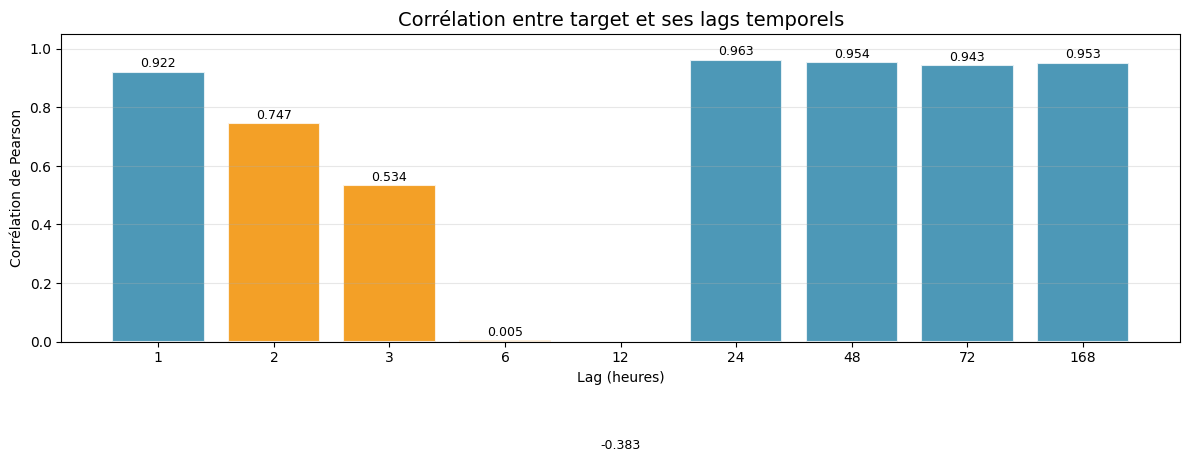

In [58]:
# Application des lag features
df_step = add_lag_features(df_step, target_col="target", lags=config.lags)

lag_cols = [col for col in df_step.columns if col.startswith("target_lag_")]
print(f"Lag features créées ({len(lag_cols)}) :")
for col in lag_cols:
    print(f"  - {col}")

print(f"\nNaN introduits par les lags :")
for col in lag_cols:
    print(f"  {col} : {df_step[col].isna().sum()} NaN")

# Visualisation : corrélation entre target et ses lags
fig, ax = plt.subplots(figsize=(12, 5))

correlations = []
for col in lag_cols:
    corr = df_step[["target", col]].dropna().corr().iloc[0, 1]
    lag_val = int(col.split("_")[-1].replace("h", ""))
    correlations.append((lag_val, corr))

corr_df = pd.DataFrame(correlations, columns=["Lag (h)", "Corrélation"])
bars = ax.bar(corr_df["Lag (h)"].astype(str), corr_df["Corrélation"],
              color=["#2E86AB" if c > 0.9 else "#A23B72" if c > 0.8 else "#F18F01" for c in corr_df["Corrélation"]],
              alpha=0.85, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, corr_df["Corrélation"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Corrélation entre target et ses lags temporels", fontsize=14)
ax.set_xlabel("Lag (heures)")
ax.set_ylabel("Corrélation de Pearson")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 11.9 Rolling features

Pour chaque fenêtre, on crée :

- **Moyenne glissante** (`_mean`)
- **Écart-type glissant** (`_std`)
- **Minimum glissant** (`_min`)
- **Maximum glissant** (`_max`)

**Fenêtres recommandées :** 3h, 6h, 12h, 24h, 48h, 168h

### Anti-data leakage

Les rolling features sont calculées sur `target.shift(1)`, ce qui signifie que la valeur cible à l'instant `t` n'entre **jamais** dans ses propres variables explicatives.

```python
shifted_target = target.shift(1)
rolling_mean_24h = shifted_target.rolling(24).mean()
```

Cette règle est vérifiée formellement dans la section de contrôle.

Rolling features créées (24) :

  Fenêtre 3h :
    - target_rolling_3h_mean
    - target_rolling_3h_std
    - target_rolling_3h_min
    - target_rolling_3h_max

  Fenêtre 6h :
    - target_rolling_6h_mean
    - target_rolling_6h_std
    - target_rolling_6h_min
    - target_rolling_6h_max

  Fenêtre 12h :
    - target_rolling_12h_mean
    - target_rolling_12h_std
    - target_rolling_12h_min
    - target_rolling_12h_max

  Fenêtre 24h :
    - target_rolling_24h_mean
    - target_rolling_24h_std
    - target_rolling_24h_min
    - target_rolling_24h_max

  Fenêtre 48h :
    - target_rolling_48h_mean
    - target_rolling_48h_std
    - target_rolling_48h_min
    - target_rolling_48h_max

  Fenêtre 168h :
    - target_rolling_168h_mean
    - target_rolling_168h_std
    - target_rolling_168h_min
    - target_rolling_168h_max


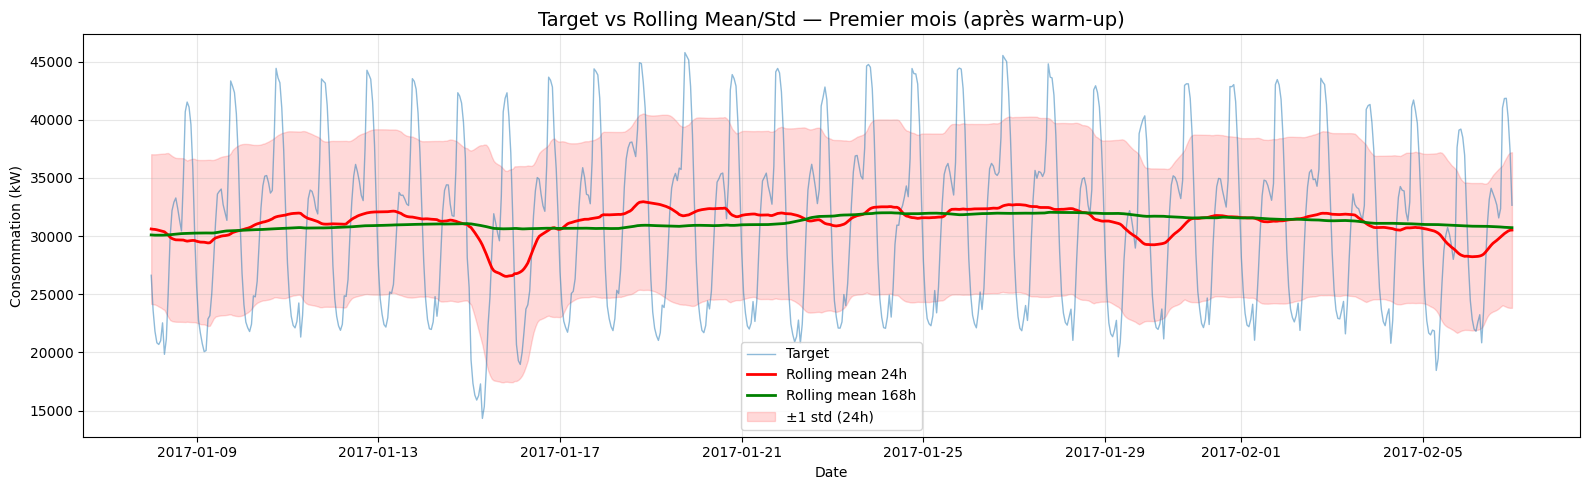

In [59]:
# Application des rolling features
df_step = add_rolling_features(df_step, target_col="target", windows=config.rolling_windows)

rolling_cols = [col for col in df_step.columns if "rolling" in col and col.startswith("target_rolling_") and "zscore" not in col]
print(f"Rolling features créées ({len(rolling_cols)}) :")

# Regrouper par fenêtre
for window in config.rolling_windows:
    window_cols = [col for col in rolling_cols if f"_{window}h_" in col]
    print(f"\n  Fenêtre {window}h :")
    for col in window_cols:
        print(f"    - {col}")

# Visualisation : rolling mean 24h vs target sur un mois
fig, ax = plt.subplots(figsize=(16, 5))

sample = df_step.dropna().iloc[:24*30]  # Premier mois sans NaN
ax.plot(sample.index, sample["target"], alpha=0.5, label="Target", linewidth=1)
ax.plot(sample.index, sample["target_rolling_24h_mean"], label="Rolling mean 24h", linewidth=2, color="red")
ax.plot(sample.index, sample["target_rolling_168h_mean"], label="Rolling mean 168h", linewidth=2, color="green")

# Bande écart-type
upper = sample["target_rolling_24h_mean"] + sample["target_rolling_24h_std"]
lower = sample["target_rolling_24h_mean"] - sample["target_rolling_24h_std"]
ax.fill_between(sample.index, lower, upper, alpha=0.15, color="red", label="±1 std (24h)")

ax.set_title("Target vs Rolling Mean/Std — Premier mois (après warm-up)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Consommation (kW)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11.10 HDD et CDD

Les variables **HDD** (Heating Degree Days) et **CDD** (Cooling Degree Days) modélisent les besoins de chauffage et de climatisation autour d'une température de base, par exemple **18°C** :

```python
HDD = max(18 - temperature, 0)
CDD = max(temperature - 18, 0)
```

**Interprétation :**

- **HDD > 0** : il fait plus froid que 18°C → besoin de chauffage → consommation accrue.
- **CDD > 0** : il fait plus chaud que 18°C → besoin de climatisation → consommation accrue.

Le seuil de 18°C est une convention classique en génie climatique.

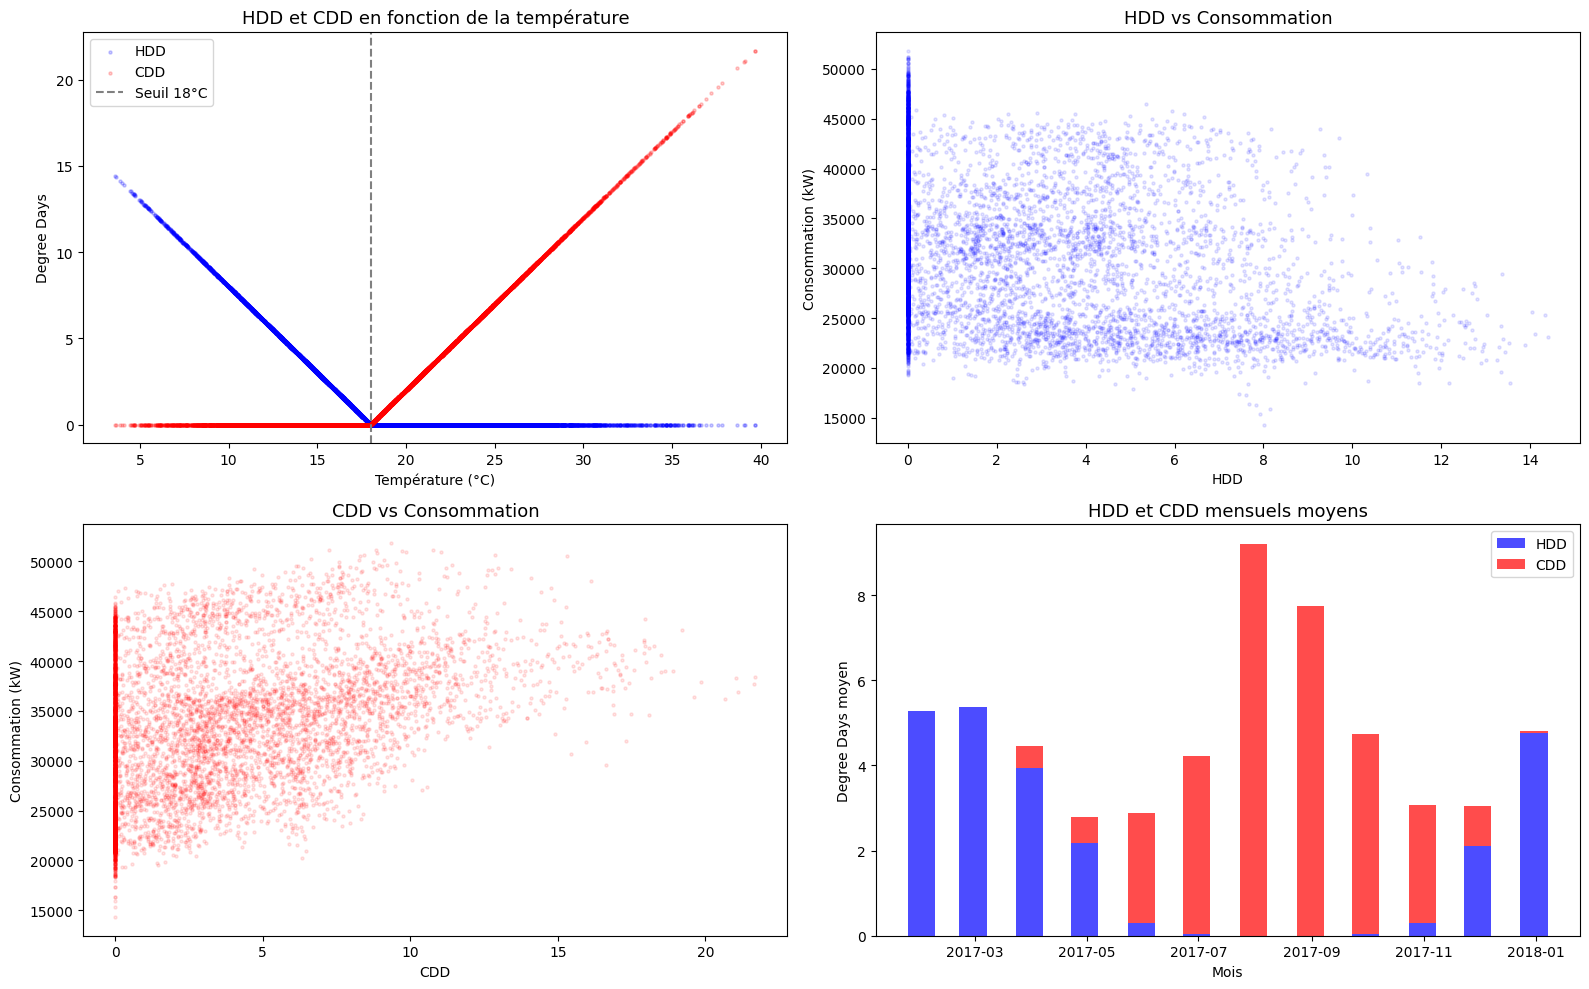


Statistiques HDD : min=0.00, max=14.40, mean=2.00
Statistiques CDD : min=0.00, max=21.70, mean=2.81


In [60]:
# Application des features météo (inclut HDD, CDD et interactions)
df_step = add_weather_features(
    df_step,
    temperature_col=config.temperature_col,
    humidity_col=config.humidity_col,
    general_diffuse_col=config.general_diffuse_col,
    diffuse_col=config.diffuse_col,
    temperature_base=config.temperature_base,
)

# Visualisation : HDD et CDD
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HDD vs CDD scatter
axes[0, 0].scatter(df_step["temperature"], df_step["HDD"], alpha=0.2, s=5, color="blue", label="HDD")
axes[0, 0].scatter(df_step["temperature"], df_step["CDD"], alpha=0.2, s=5, color="red", label="CDD")
axes[0, 0].axvline(x=18, color="gray", linestyle="--", label="Seuil 18°C")
axes[0, 0].set_title("HDD et CDD en fonction de la température", fontsize=13)
axes[0, 0].set_xlabel("Température (°C)")
axes[0, 0].set_ylabel("Degree Days")
axes[0, 0].legend()

# HDD vs target
axes[0, 1].scatter(df_step["HDD"], df_step["target"], alpha=0.1, s=5, color="blue")
axes[0, 1].set_title("HDD vs Consommation", fontsize=13)
axes[0, 1].set_xlabel("HDD")
axes[0, 1].set_ylabel("Consommation (kW)")

# CDD vs target
axes[1, 0].scatter(df_step["CDD"], df_step["target"], alpha=0.1, s=5, color="red")
axes[1, 0].set_title("CDD vs Consommation", fontsize=13)
axes[1, 0].set_xlabel("CDD")
axes[1, 0].set_ylabel("Consommation (kW)")

# Évolution temporelle HDD / CDD
monthly_hdd = df_step.resample("ME")["HDD"].mean()
monthly_cdd = df_step.resample("ME")["CDD"].mean()
axes[1, 1].bar(monthly_hdd.index, monthly_hdd.values, width=15, label="HDD", color="blue", alpha=0.7)
axes[1, 1].bar(monthly_cdd.index, monthly_cdd.values, width=15, label="CDD", color="red", alpha=0.7, bottom=monthly_hdd.values)
axes[1, 1].set_title("HDD et CDD mensuels moyens", fontsize=13)
axes[1, 1].set_xlabel("Mois")
axes[1, 1].set_ylabel("Degree Days moyen")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nStatistiques HDD : min={df_step["HDD"].min():.2f}, max={df_step["HDD"].max():.2f}, mean={df_step["HDD"].mean():.2f}")
print(f"Statistiques CDD : min={df_step["CDD"].min():.2f}, max={df_step["CDD"].max():.2f}, mean={df_step["CDD"].mean():.2f}")

## 11.11 Interactions météo

Les interactions météo capturent des effets combinés :

| Variable | Formule | Rôle |
|----------|---------|------|
| `temperature_humidity_interaction` | température × humidité | Inconfort thermique ressenti |
| `temperature_peak_interaction` | température × heure de pointe | Effet amplifié en pointe |
| `CDD_peak_interaction` | CDD × heure de pointe | Climatisation en pointe |
| `HDD_peak_interaction` | HDD × heure de pointe | Chauffage en pointe |
| `general_diffuse_month_interaction` | flux diffus × mois | Saisonnalité solaire |
| `diffuse_month_interaction` | flux diffus × mois | Saisonnalité solaire |

**Lags météo :** L'effet thermique peut être retardé. Des lags de 1h, 2h, 3h, 6h et 12h sont ajoutés pour la température, l'humidité, HDD et CDD.

**Interprétation :** Ces variables permettent au modèle de capturer des effets non-linéaires entre la météo et l'heure de la journée.

Nombre de features d'interactions et lags météo : 26
  - temperature_humidity_interaction
  - temperature_peak_interaction
  - CDD_peak_interaction
  - HDD_peak_interaction
  - general_diffuse_month_interaction
  - diffuse_month_interaction
  - temperature_lag_1h
  - humidity_lag_1h
  - HDD_lag_1h
  - CDD_lag_1h
  - temperature_lag_2h
  - humidity_lag_2h
  - HDD_lag_2h
  - CDD_lag_2h
  - temperature_lag_3h
  - humidity_lag_3h
  - HDD_lag_3h
  - CDD_lag_3h
  - temperature_lag_6h
  - humidity_lag_6h
  - HDD_lag_6h
  - CDD_lag_6h
  - temperature_lag_12h
  - humidity_lag_12h
  - HDD_lag_12h
  - CDD_lag_12h


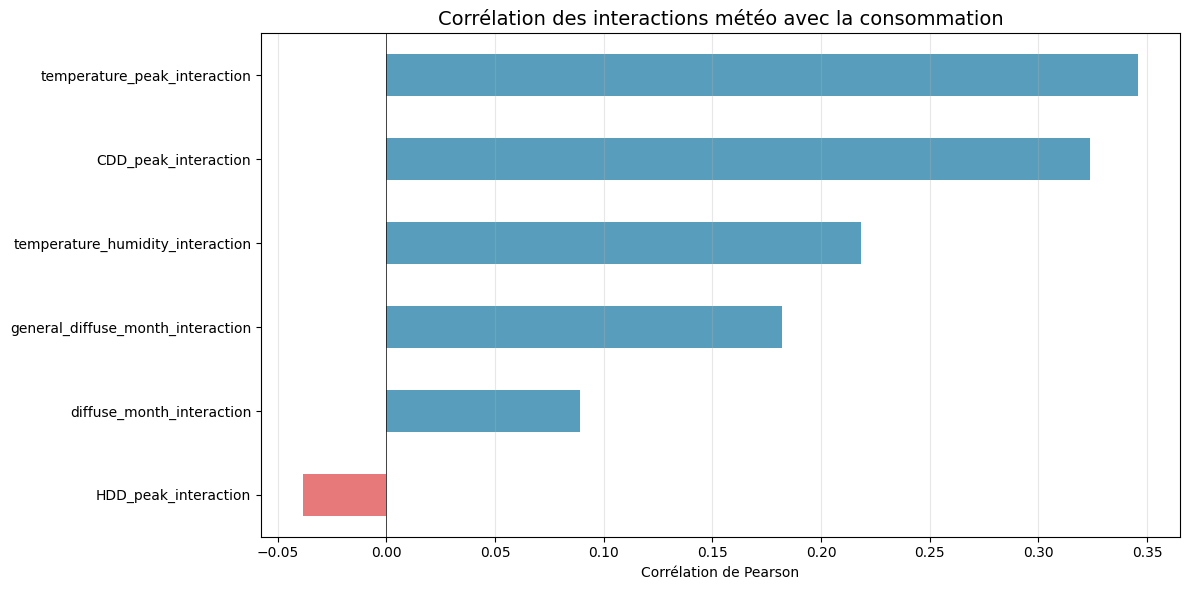

In [61]:
# Les interactions météo ont été créées par add_weather_features
interaction_cols = [
    col for col in df_step.columns
    if "interaction" in col
    or (col.startswith("temperature_lag_") or col.startswith("humidity_lag_")
        or col.startswith("HDD_lag_") or col.startswith("CDD_lag_"))
]

print(f"Nombre de features d'interactions et lags météo : {len(interaction_cols)}")
for col in interaction_cols:
    print(f"  - {col}")

# Visualisation : heatmap des corrélations entre target et interactions
fig, ax = plt.subplots(figsize=(12, 6))

interaction_only = [c for c in interaction_cols if "interaction" in c]
corr_data = df_step[["target"] + interaction_only].dropna().corr()["target"].drop("target")

corr_data.sort_values().plot(kind="barh", ax=ax, color=["#2E86AB" if v > 0 else "#E15759" for v in corr_data.sort_values()], alpha=0.8)
ax.set_title("Corrélation des interactions météo avec la consommation", fontsize=14)
ax.set_xlabel("Corrélation de Pearson")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 11.12 Variables de robustesse

Variables utiles pour les tests de robustesse :

| Variable | Description |
|----------|-------------|
| `is_high_temperature` | 1 si température ≥ 30°C |
| `eval_is_high_load` | 1 si charge ≥ quantile 95% (train) |
| `is_heatwave_simulated` | Indicateur de vague de chaleur simulée (réservé) |

**⚠️ Attention :** `eval_is_high_load` est dérivée de la cible. Elle sert **uniquement** à découper l'évaluation et **ne doit pas** être utilisée comme feature modèle.

Variables de robustesse :
  is_high_temperature : 239 heures (2.7%)
  eval_is_high_load   : 392 heures (4.5%)
  Seuil haute température : 30.0°C
  Seuil forte charge (Q95 train) : 44816.11 kW


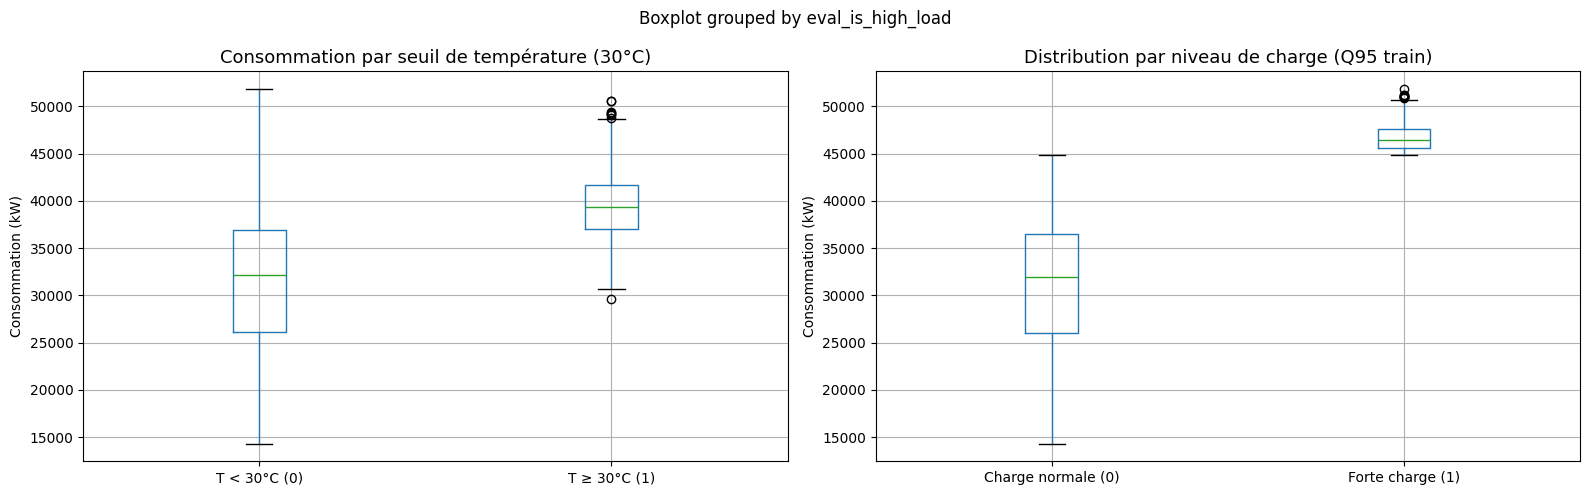

In [62]:
# Application des flags de robustesse
df_step = add_robustness_flags(
    df_step,
    target_col=config.target_col,
    high_temperature_threshold=config.high_temperature_threshold,
    high_load_threshold=high_load_threshold_train,
)

print("Variables de robustesse :")
print(f"  is_high_temperature : {df_step["is_high_temperature"].sum()} heures ({df_step["is_high_temperature"].mean()*100:.1f}%)")
print(f"  eval_is_high_load   : {df_step["eval_is_high_load"].sum()} heures ({df_step["eval_is_high_load"].mean()*100:.1f}%)")
print(f"  Seuil haute température : {config.high_temperature_threshold}°C")
print(f"  Seuil forte charge (Q95 train) : {high_load_threshold_train:.2f} kW")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_step.boxplot(column="target", by="is_high_temperature", ax=axes[0])
axes[0].set_xticklabels(["T < 30°C (0)", "T ≥ 30°C (1)"])
axes[0].set_title("Consommation par seuil de température (30°C)", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Consommation (kW)")
plt.suptitle("")

df_step.boxplot(column="target", by="eval_is_high_load", ax=axes[1])
axes[1].set_xticklabels(["Charge normale (0)", "Forte charge (1)"])
axes[1].set_title("Distribution par niveau de charge (Q95 train)", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Consommation (kW)")

plt.tight_layout()
plt.show()

## 11.13 Point méthodologique important

> **Les variables d'activité humaine ne sont pas des observations directes dans le dataset Tetouan.**
>
> Elles sont représentées par des **proxys temporels et calendaires** :
>
> - heure, jour de semaine, week-end
> - saison, mois, trimestre
> - jours fériés marocains
> - heures de pointe et heures creuses
> - lags journaliers et hebdomadaires
>
> Cette décision doit être **explicitement mentionnée** dans le rapport final et la soutenance.

Les cycles d'activité humaine (heures de travail, heures de repos, habitudes de consommation) ne sont pas mesurés directement par les capteurs. Le Feature Engineering crée des approximations raisonnables à partir de l'horodatage.

---
## 12. Construction du dataset final via le pipeline complet

Le pipeline `build_feature_dataset` de `src/features.py` exécute toutes les étapes ci-dessus en une seule fonction.

Le résultat est un dataset supervisé prêt pour la modélisation, avec suppression automatique des lignes NaN introduites par les lags et rolling features.

**Colonnes exclues des features modèle :**

- `zone1_power`, `zone2_power`, `zone3_power`, `total_load` (fuite de cible)
- `target` (variable à prédire)
- `eval_is_high_load`, `is_heatwave_simulated` (réservées à l'évaluation)
- `season` (catégorielle, remplacée par les dummies)
- Colonnes de diagnostic issues du prétraitement

In [63]:
# Pipeline complet
df_features = build_feature_dataset(
    df_hourly,
    config=config,
    holidays=holidays,
    high_load_threshold=high_load_threshold_train,
)

# Features modèle
feature_cols = get_model_feature_columns(df_features, target_col="target")

print(f"Dimensions avant feature engineering : {df_hourly.shape}")
print(f"Dimensions après feature engineering : {df_features.shape}")
print(f"Nombre de features utilisables par les modèles : {len(feature_cols)}")

rows_dropped = df_features.attrs.get("rows_dropped_after_features", "inconnu")
print(f"Lignes supprimées à cause des lags/rolling : {rows_dropped}")

display(df_features.head(3))

Dimensions avant feature engineering : (8736, 15)
Dimensions après feature engineering : (8568, 111)
Nombre de features utilisables par les modèles : 98
Lignes supprimées à cause des lags/rolling : 168


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,zone1_power,zone2_power,zone3_power,target,total_load,target_rolling_zscore,total_load_rolling_zscore,is_target_outlier,is_total_load_outlier,is_load_outlier,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,is_business_hour,is_morning_peak,is_evening_peak,is_peak_hour,is_off_peak,is_night,season,season_code,season_autumn,season_spring,season_summer,season_winter,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_holiday,is_day_before_holiday,is_day_after_holiday,days_to_nearest_holiday,target_lag_1h,target_lag_2h,target_lag_3h,target_lag_6h,target_lag_12h,target_lag_24h,target_lag_48h,target_lag_72h,target_lag_168h,target_rolling_3h_mean,target_rolling_3h_std,target_rolling_3h_min,target_rolling_3h_max,target_rolling_6h_mean,target_rolling_6h_std,target_rolling_6h_min,target_rolling_6h_max,target_rolling_12h_mean,target_rolling_12h_std,target_rolling_12h_min,target_rolling_12h_max,target_rolling_24h_mean,target_rolling_24h_std,target_rolling_24h_min,target_rolling_24h_max,target_rolling_48h_mean,target_rolling_48h_std,target_rolling_48h_min,target_rolling_48h_max,target_rolling_168h_mean,target_rolling_168h_std,target_rolling_168h_min,target_rolling_168h_max,HDD,CDD,temperature_humidity_interaction,temperature_peak_interaction,CDD_peak_interaction,HDD_peak_interaction,general_diffuse_month_interaction,diffuse_month_interaction,temperature_lag_1h,humidity_lag_1h,HDD_lag_1h,CDD_lag_1h,temperature_lag_2h,humidity_lag_2h,HDD_lag_2h,CDD_lag_2h,temperature_lag_3h,humidity_lag_3h,HDD_lag_3h,CDD_lag_3h,temperature_lag_6h,humidity_lag_6h,HDD_lag_6h,CDD_lag_6h,temperature_lag_12h,humidity_lag_12h,HDD_lag_12h,CDD_lag_12h,is_high_temperature,is_heatwave_simulated,eval_is_high_load
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.273333,77.916667,0.0880,0.044667,0.123667,26633.924052,17421.276597,17871.807228,26633.924052,61927.007877,2.046826,2.097893,0.0,0.0,0.0,0,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.000000,1.000000,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,31526.075950,36025.316455,39227.341773,41583.797468,34033.417720,27193.924052,27172.658228,25979.746835,29197.974683,35592.911393,3158.861021,31526.075950,39227.341773,38309.704641,3528.606271,31526.075950,41583.797468,35676.624472,3851.666111,30612.658228,41583.797468,30612.700422,6430.701095,21502.78481,41583.797468,30662.468354,6600.138307,21453.164557,42924.556962,30102.121760,6962.283109,18540.759495,43572.658227,3.726667,0.0,1112.130556,0.0,0.0,0.0,0.044667,0.123667,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,13.070000,77.166667,4.930000,0.0,13.701667,72.591667,4.298333,0.0,14.575000,67.718333,3.425000,0.0,0,0,0
2017-01-08 01:00:00,14.441667,76.616667,0.0910,0.046500,0.137000,23640.506328,15492.401215,16057.831327,23640.506328,55190.738870,1.593769,1.616170,0.0,0.0,0.0,1,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.258819,0.965926,-0.781831,0.62349,0.0,1.0,0.137279,0.990532,0,0,0,3,26633.924052,31526.075950,36025.316455,40846.582277,33486.582277,23961.518987,23968.607595,22892.151898,24657.215190,31395.105486,3835.138221,26633.924052,36025.316455,35818.059072,5213.136547,26633.924052,40846.582277,35060.000000,4587.406453,26633.924052,41583.797468,30589.367088,6444.065618,21502.78481,41583.797468,30651.244726,6606.518215,21453.164557,42924.556962,30086.859554,6967.057111,18540.759495,43572.658227,3.558333,0.0,1106.472361,0.0,0.0,0.0,0.046500,0.137000,14.273333,77.916667,3.726667,0.0,13.530000,78.583333,4.470000,0.0,13.023333,78.316667,4.976667,0.0,11.993333,79.133333,6.006667,0.0,14.928333,61.946667,3.071667,0.0,0,0,0
2017-01-08 02:00:00,14.216667,74.183333,0.0885,0.045833,0.123667,21817.721520,14072.340427,15021.686747,21817.721520,50911.748693,1.317991,1.359114,0.0,0.0,0.0,2,6,8,8,1,1,1,1,0,0,0,0,1,1,winter,0,0,0,0,1,0.500000,0.866025

## 13. Contrôles de cohérence

### 13.1 Validation générale

Le module `validate_feature_dataset` vérifie :

- DatetimeIndex ;
- Ordre chronologique ;
- Absence de doublons ;
- Présence de la cible ;
- Absence de NaN ;
- Absence de valeurs infinies.

In [64]:
# Validation
validation_report = validate_feature_dataset(
    df_features,
    target_col="target",
    feature_cols=feature_cols,
)

print("Rapport de validation :")
for key, value in validation_report.items():
    print(f"  {key} : {value}")

print("\n✅ Dataset validé avec succès.")

Rapport de validation :
  n_rows : 8568
  n_columns : 111
  start : 2017-01-08 00:00:00
  end : 2017-12-30 23:00:00
  target_col : target
  n_model_features : 98
  n_missing : 0
  n_infinite : 0
  inferred_frequency : h

✅ Dataset validé avec succès.


### 13.2 Vérification anti-data leakage

On vérifie formellement que les rolling means sont calculées avec `target.shift(1)` :

```python
expected = target.shift(1).rolling(window).mean()
actual = target_rolling_{window}h_mean
assert allclose(expected, actual)
```

In [65]:
# Vérification anti-data leakage
leakage_report = check_rolling_no_leakage(
    df_features,
    target_col="target",
    windows=config.rolling_windows,
)

print("Test anti-data leakage sur les rolling features :")
for col, passed in leakage_report.items():
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"  {col} : {status}")

if all(leakage_report.values()):
    print("\n✅ Aucune fuite de données détectée dans les rolling features.")
else:
    print("\n❌ ATTENTION : Fuite de données détectée ! Vérifier le calcul des rolling features.")

Test anti-data leakage sur les rolling features :
  target_rolling_3h_mean : ✅ PASS
  target_rolling_6h_mean : ✅ PASS
  target_rolling_12h_mean : ✅ PASS
  target_rolling_24h_mean : ✅ PASS
  target_rolling_48h_mean : ✅ PASS
  target_rolling_168h_mean : ✅ PASS

✅ Aucune fuite de données détectée dans les rolling features.


## 14. Aperçu des features créées

Résumé complet des features disponibles pour la modélisation.

Nombre total de colonnes : 111
Nombre de features modèle : 98

Features par catégorie :

  Météo brutes (5) :
    - temperature
    - humidity
    - wind_speed
    - general_diffuse_flows
    - diffuse_flows

  Temporelles (7) :
    - hour
    - dayofweek
    - dayofmonth
    - dayofyear
    - weekofyear
    - month
    - quarter

  Cycliques sin/cos (8) :
    - hour_sin
    - hour_cos
    - dow_sin
    - dow_cos
    - month_sin
    - month_cos
    - doy_sin
    - doy_cos

  Indicateurs binaires (16) :
    - is_weekend
    - is_business_hour
    - is_morning_peak
    - is_evening_peak
    - is_peak_hour
    - is_off_peak
    - is_night
    - season_code
    - season_autumn
    - season_spring
    - season_summer
    - season_winter
    - is_holiday
    - is_day_before_holiday
    - is_day_after_holiday
    - is_high_temperature

  Jours fériés (4) :
    - is_holiday
    - is_day_before_holiday
    - is_day_after_holiday
    - days_to_nearest_holiday

  Lags target (9) :
    - target_la

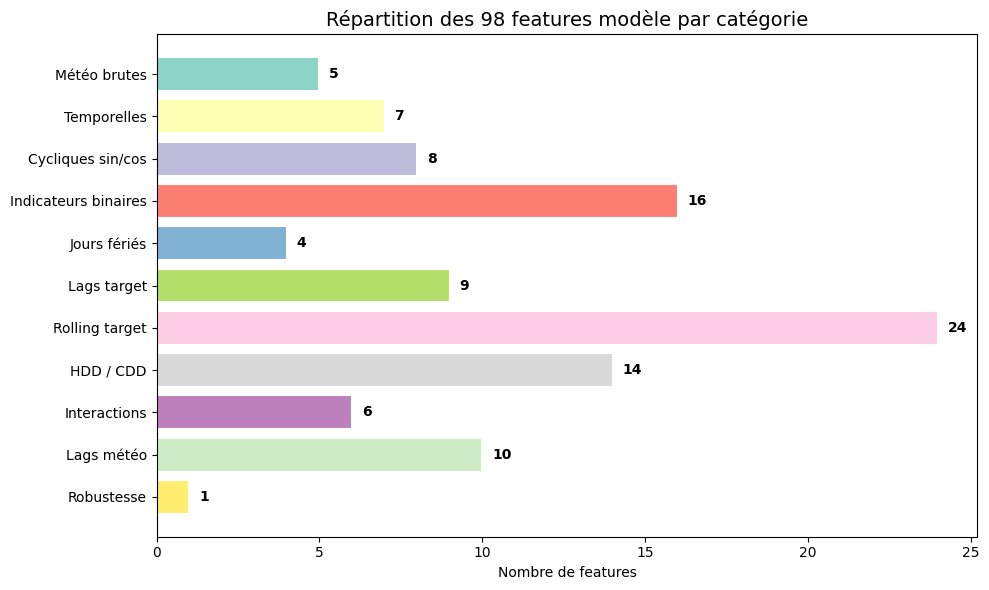

In [66]:
print(f"Nombre total de colonnes : {df_features.shape[1]}")
print(f"Nombre de features modèle : {len(feature_cols)}")

# Classement par catégorie
categories = {
    "Météo brutes": [c for c in feature_cols if c in ["temperature", "humidity", "wind_speed", "general_diffuse_flows", "diffuse_flows"]],
    "Temporelles": [c for c in feature_cols if c in ["hour", "dayofweek", "dayofmonth", "dayofyear", "weekofyear", "month", "quarter"]],
    "Cycliques sin/cos": [c for c in feature_cols if "_sin" in c or "_cos" in c],
    "Indicateurs binaires": [c for c in feature_cols if c.startswith("is_") or c.startswith("season_")],
    "Jours fériés": [c for c in feature_cols if "holiday" in c],
    "Lags target": [c for c in feature_cols if c.startswith("target_lag_")],
    "Rolling target": [c for c in feature_cols if c.startswith("target_rolling_") and "zscore" not in c],
    "HDD / CDD": [c for c in feature_cols if c in ["HDD", "CDD"] or c.startswith("HDD_") or c.startswith("CDD_")],
    "Interactions": [c for c in feature_cols if "interaction" in c],
    "Lags météo": [c for c in feature_cols if c.startswith("temperature_lag_") or c.startswith("humidity_lag_")],
    "Robustesse": [c for c in feature_cols if c == "is_high_temperature"],
}

print("\nFeatures par catégorie :")
for cat, cols in categories.items():
    print(f"\n  {cat} ({len(cols)}) :")
    for col in cols:
        print(f"    - {col}")

# Résumé visuel
fig, ax = plt.subplots(figsize=(10, 6))
cat_counts = {k: len(v) for k, v in categories.items() if len(v) > 0}
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
bars = ax.barh(list(cat_counts.keys()), list(cat_counts.values()), color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, cat_counts.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val),
            ha="left", va="center", fontsize=10, fontweight="bold")
ax.set_title(f"Répartition des {len(feature_cols)} features modèle par catégorie", fontsize=14)
ax.set_xlabel("Nombre de features")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 15. Sauvegarde du dataset features

Le fichier sauvegardé sera utilisé par les notebooks suivants :

- `05_modeling_sarima_prophet.ipynb`
- `06_modeling_ml_xgboost.ipynb`
- `07_modeling_gru.ipynb`

La liste des features modèles est sauvegardée dans `data/processed/feature_columns.txt`.

In [67]:
# Sauvegarde du dataset
features_path = save_feature_dataset(df_features, FEATURES_PATH)

# Sauvegarde de la liste des features
FEATURE_COLUMNS_PATH.write_text(
    "\n".join(feature_cols),
    encoding="utf-8",
)

print(f"Dataset enrichi sauvegardé : {features_path}")
print(f"Liste des features modèle sauvegardée : {FEATURE_COLUMNS_PATH}")
print(f"Taille du fichier : {features_path.stat().st_size / 1024 / 1024:.1f} Mo")

Dataset enrichi sauvegardé : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\tetouan_features.csv
Liste des features modèle sauvegardée : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\feature_columns.txt
Taille du fichier : 11.1 Mo


---
## 16. Baselines naïves

Les baselines naïves servent de **minimum de performance**.

| Baseline | Lag | Description |
|----------|-----|-------------|
| `naive_previous_hour` | 1h | Prédit target(t-1) |
| `naive_previous_day` | 24h | Prédit target(t-24) |
| `naive_previous_week` | 168h | Prédit target(t-168) |

**Règle :** Un modèle avancé qui ne dépasse pas ces baselines n'apporte pas de valeur métier suffisante.

In [68]:
# Évaluation des baselines naïves
baseline_metrics, baseline_predictions = evaluate_naive_baselines(
    df_features,
    target_col="target",
    train_ratio=0.70,
    val_ratio=0.15,
)

# Sauvegarde
save_baseline_outputs(
    baseline_metrics,
    baseline_predictions,
    BASELINE_METRICS_PATH,
    BASELINE_PRED_PATH,
)

print(f"Métriques baseline sauvegardées : {BASELINE_METRICS_PATH}")
print(f"Prédictions baseline sauvegardées : {BASELINE_PRED_PATH}")

print("\nMétriques des baselines naïves :")
display(baseline_metrics)

Métriques baseline sauvegardées : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\results\metrics\baseline_naive_metrics.csv
Prédictions baseline sauvegardées : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\results\predictions\baseline_naive_predictions.csv

Métriques des baselines naïves :


,model,n_test_obs,MAE,RMSE,MAPE,R2
0,naive_previous_week,1286,792.878790,1098.376378,2.781035,0.966537
1,naive_previous_day,1286,935.394377,1434.901033,3.271021,0.942891
2,naive_previous_hour,1286,1745.006648,2300.125141,6.015784,0.853255


## 17. Visualisation : première semaine de test

Cette figure permet de vérifier visuellement si les baselines suivent correctement la saisonnalité de la cible.

On affiche la première semaine du test set.

Figure sauvegardée : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\results\figures\baseline_naive_test_week.png


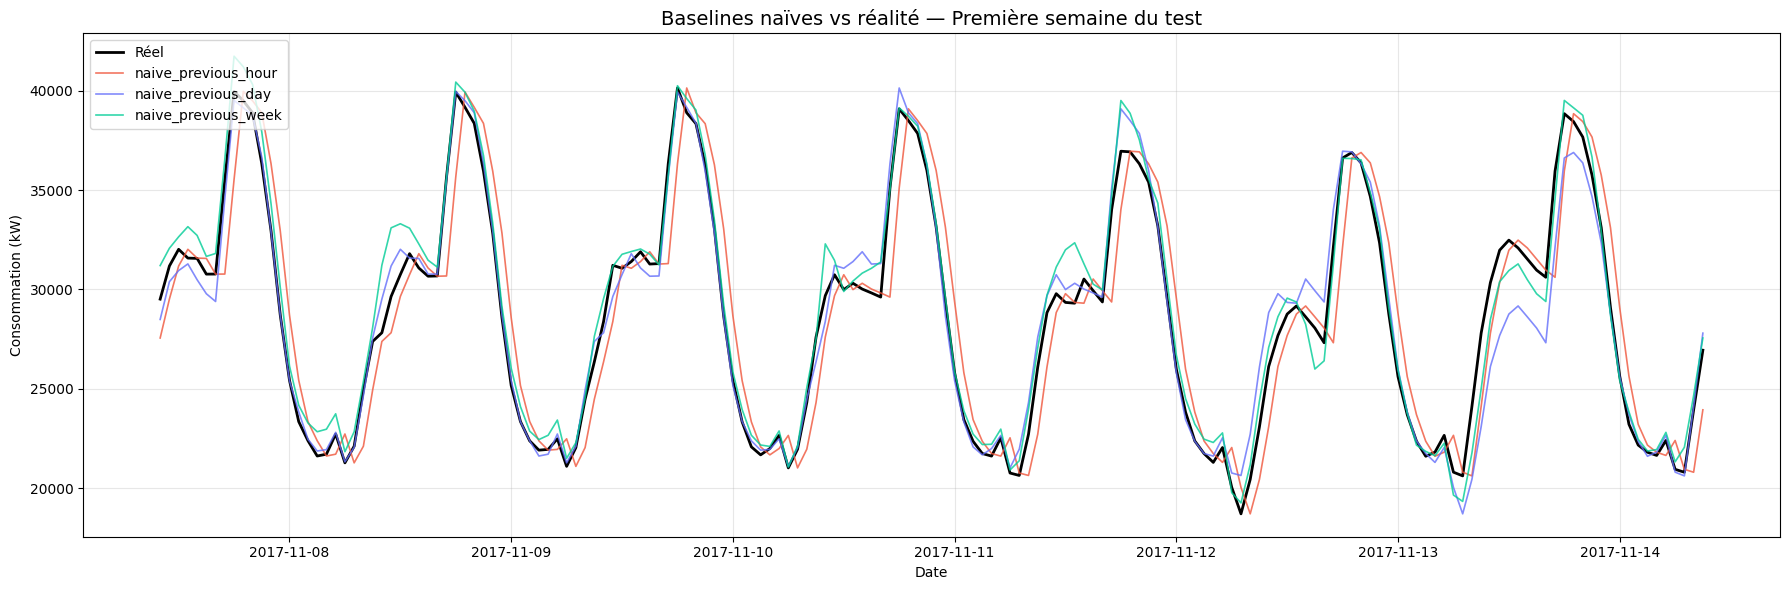

In [69]:
# Visualisation sur la première semaine du test
plot_df = baseline_predictions.dropna().copy().iloc[: 24 * 7]

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(plot_df.index, plot_df["y_true"], label="Réel", linewidth=2, color="black")

colors = ["#EF553B", "#636EFA", "#00CC96"]
for i, col in enumerate(["naive_previous_hour", "naive_previous_day", "naive_previous_week"]):
    if col in plot_df.columns:
        ax.plot(plot_df.index, plot_df[col], label=col, linewidth=1.2, alpha=0.8, color=colors[i])

ax.set_title("Baselines naïves vs réalité — Première semaine du test", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Consommation (kW)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASELINE_FIG_PATH, dpi=150, bbox_inches="tight")
print(f"Figure sauvegardée : {BASELINE_FIG_PATH}")
plt.show()

## 18. Analyse des résultats baseline

Meilleure baseline naïve :
  Modèle : naive_previous_week
  MAE    : 792.88
  RMSE   : 1098.38
  MAPE   : 2.78%
  R²     : 0.9665

Interprétation :
Cette baseline représente le seuil minimal à battre par les modèles avancés comme SARIMAX, Prophet, Random Forest, XGBoost et GRU.


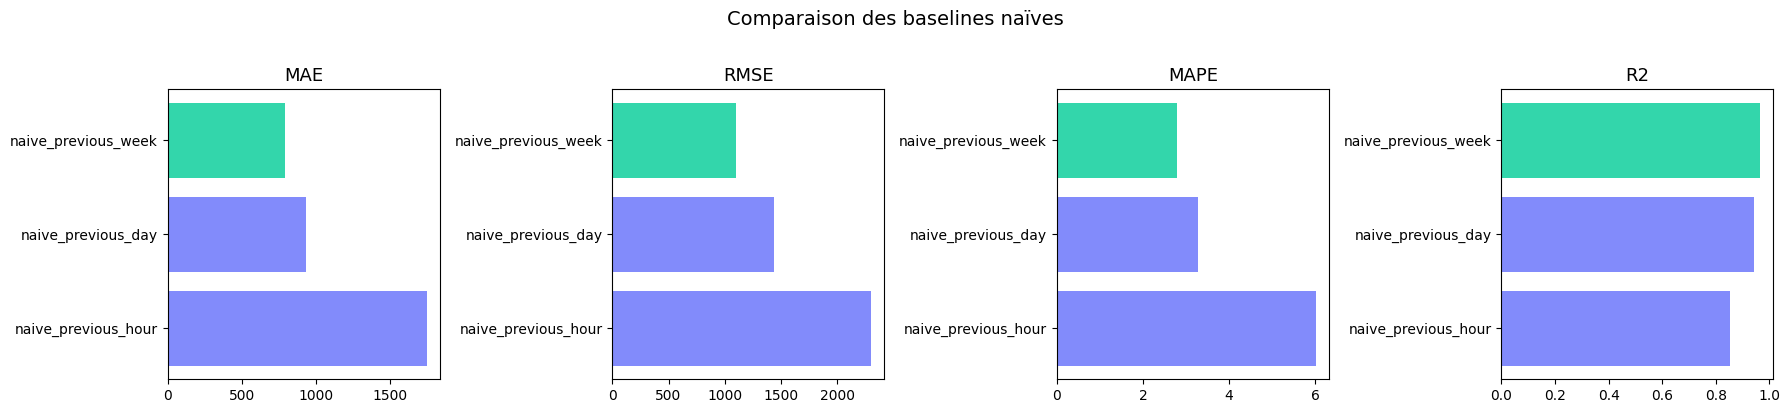

In [70]:
# Meilleure baseline
best_baseline = baseline_metrics.iloc[0]

print("Meilleure baseline naïve :")
print(f"  Modèle : {best_baseline['model']}")
print(f"  MAE    : {best_baseline['MAE']:.2f}")
print(f"  RMSE   : {best_baseline['RMSE']:.2f}")
print(f"  MAPE   : {best_baseline['MAPE']:.2f}%")
print(f"  R²     : {best_baseline['R2']:.4f}")

print("\nInterprétation :")
print(
    "Cette baseline représente le seuil minimal à battre par les modèles avancés "
    "comme SARIMAX, Prophet, Random Forest, XGBoost et GRU."
)

# Comparaison visuelle des métriques
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, metric in enumerate(["MAE", "RMSE", "MAPE", "R2"]):
    colors = ["#00CC96" if v == baseline_metrics[metric].min() else "#636EFA" for v in baseline_metrics[metric]]
    if metric == "R2":
        colors = ["#00CC96" if v == baseline_metrics[metric].max() else "#636EFA" for v in baseline_metrics[metric]]

    axes[i].barh(baseline_metrics["model"], baseline_metrics[metric], color=colors, alpha=0.8)
    axes[i].set_title(metric, fontsize=13)
    axes[i].invert_yaxis()

plt.suptitle("Comparaison des baselines naïves", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 19. Synthèse pour le rapport final

### Résumé du Feature Engineering

Le feature engineering transforme la série horaire propre en dataset supervisé. Les variables calendaires et cycliques représentent les cycles d'activité humaine absents du dataset brut. Les lags et rolling features capturent la mémoire de la consommation, tandis que HDD/CDD modélisent la sensibilité thermique autour d'une température de confort de 18°C.

### Anti-data leakage

Les rolling statistics sont calculées avec `shift(1)`, ce qui empêche la valeur cible actuelle d'entrer dans ses propres variables explicatives.

### Baselines

Les baselines naïves fournissent un seuil minimal de performance que les modèles SARIMAX, Prophet, Random Forest/XGBoost et GRU devront dépasser.

### Point méthodologique

Les variables d'activité humaine ne sont pas directement observées dans le dataset Tetouan. Elles sont approximées par des proxys temporels et calendaires : heure, jour de semaine, week-end, saison, jours fériés, heures de pointe, heures creuses, lags journaliers et hebdomadaires.

### Prochaines étapes

- `05_modeling_sarima_prophet.ipynb` : Modèles statistiques
- `06_modeling_ml_xgboost.ipynb` : Machine Learning tabulaire
- `07_modeling_gru.ipynb` : Deep Learning (GRU)